In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [30]:
df = pd.read_csv("used_cars.csv")

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [34]:
df.shape 



(4009, 12)

In [32]:
df.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='str')

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 892.6 KB


In [36]:
df.isnull().sum()


brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [37]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["price"].head()

0    10300.0
1    38005.0
2    54598.0
3    15500.0
4    34999.0
Name: price, dtype: float64

In [38]:
df["milage"] = (
    df["milage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" mi.", "", regex=False)
    .astype(float)
)

df["milage"].head()

0    51000.0
1    34742.0
2    22372.0
3    88900.0
4     9835.0
Name: milage, dtype: float64

In [39]:
df.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


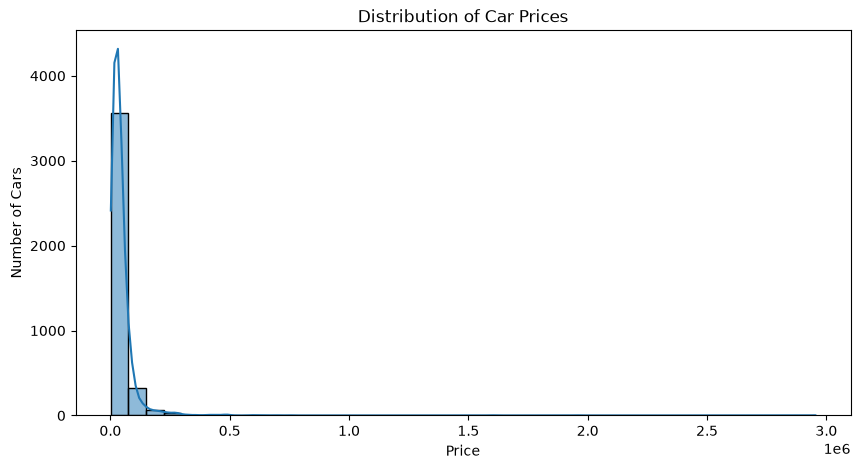

In [40]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=40, kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

In [41]:
numeric_cols = ["model_year", "milage", "price"]

df[numeric_cols].corr()

,model_year,milage,price
model_year,1.000000,-0.617720,0.199496
milage,-0.617720,1.000000,-0.305528
price,0.199496,-0.305528,1.000000


In [42]:
X = df.drop("price", axis=1)
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (4009, 11)
y shape: (4009,)


In [43]:
numerical_features = [
    "model_year",
    "milage"
]

categorical_features = [
    "brand",
    "model",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['model_year', 'milage']

Categorical features:
['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3207, 11)
Testing data: (802, 11)


In [46]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)




In [48]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)


In [49]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2  :", round(linear_r2, 4))


MAE : 19744.9
RMSE: 138034.55
R2  : 0.0678


In [51]:
svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR(kernel="rbf"))
    ]
)

svr_model.fit(X_train, y_train)

svr_pred = svr_model.predict(X_test)


In [52]:
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2 = r2_score(y_test, svr_pred)

print("MAE :", round(svr_mae, 2))
print("RMSE:", round(svr_rmse, 2))
print("R2  :", round(svr_r2, 4))

MAE : 32779.68
RMSE: 144195.03
R2  : -0.0173


In [53]:
dt_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=15,
            random_state=42
        ))
    ]
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


In [54]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("MAE :", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))
print("R2  :", round(dt_r2, 4))

MAE : 22870.82
RMSE: 137159.04
R2  : 0.0796


In [56]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)



In [57]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2  :", round(rf_r2, 4))

MAE : 20118.6
RMSE: 134892.83
R2  : 0.1098


In [59]:
bagging_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", BaggingRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

bagging_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)



In [60]:
bagging_mae = mean_absolute_error(y_test, bagging_pred)
bagging_rmse = np.sqrt(mean_squared_error(y_test, bagging_pred))
bagging_r2 = r2_score(y_test, bagging_pred)

print("MAE :", round(bagging_mae, 2))
print("RMSE:", round(bagging_rmse, 2))
print("R2  :", round(bagging_r2, 4))


MAE : 19038.52
RMSE: 134817.44
R2  : 0.1108


In [62]:
boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)


In [63]:
boosting_mae = mean_absolute_error(y_test, boosting_pred)
boosting_rmse = np.sqrt(mean_squared_error(y_test, boosting_pred))
boosting_r2 = r2_score(y_test, boosting_pred)

print("MAE :", round(boosting_mae, 2))
print("RMSE:", round(boosting_rmse, 2))
print("R2  :", round(boosting_r2, 4))


MAE : 23292.27
RMSE: 135858.78
R2  : 0.097


In [64]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "SVR",
        "Decision Tree",
        "Random Forest",
        "Bagging",
        "Boosting"
    ],
    "MAE": [
        linear_mae,
        svr_mae,
        dt_mae,
        rf_mae,
        bagging_mae,
        boosting_mae
    ],
    "RMSE": [
        linear_rmse,
        svr_rmse,
        dt_rmse,
        rf_rmse,
        bagging_rmse,
        boosting_rmse
    ],
    "R2": [
        linear_r2,
        svr_r2,
        dt_r2,
        rf_r2,
        bagging_r2,
        boosting_r2
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
4,Bagging,19038.518766,134817.442166,0.110757
3,Random Forest,20118.599037,134892.828335,0.109762
5,Boosting,23292.270214,135858.782971,0.096967
2,Decision Tree,22870.818008,137159.041970,0.079599
0,Linear Regression,19744.895889,138034.550676,0.067811
1,SVR,32779.681830,144195.034662,-0.017253


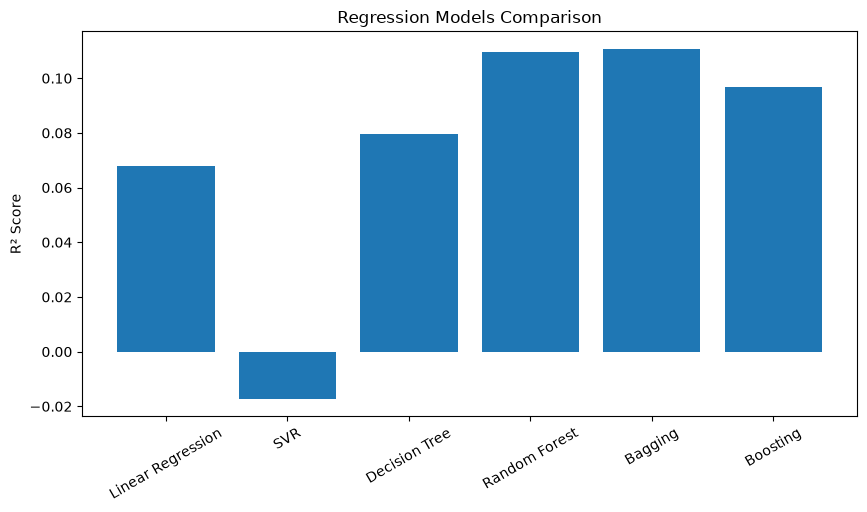

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(results["Model"], results["R2"])

plt.xticks(rotation=30)
plt.ylabel("R² Score")
plt.title("Regression Models Comparison")
plt.show()

In [66]:
best_model_name = results.loc[
    results["R2"].idxmax(), "Model"
]

best_model_r2 = results["R2"].max()

print("Best Model:", best_model_name)
print("Best R2:", round(best_model_r2, 4))

Best Model: Bagging
Best R2: 0.1108


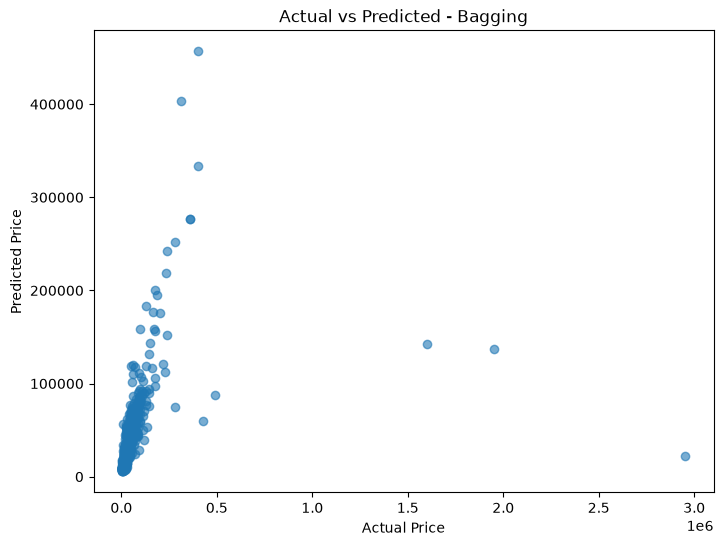

In [67]:
best_predictions = {
    "Linear Regression": linear_pred,
    "SVR": svr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Bagging": bagging_pred,
    "Boosting": boosting_pred
}

best_pred = best_predictions[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_pred, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted - {best_model_name}")

plt.show()

In [68]:
#CLASSFCATION
q1 = df["price"].quantile(0.33)
q2 = df["price"].quantile(0.66)

print("Budget upper limit :", q1)
print("Medium upper limit :", q2)

Budget upper limit : 21500.0
Medium upper limit : 42000.0


In [69]:
def price_category(price):
    if price <= q1:
        return "Budget"
    elif price <= q2:
        return "Medium"
    else:
        return "Premium"


df["price_category"] = df["price"].apply(price_category)

df[["price", "price_category"]].head(10)

,price,price_category
0,10300.0,Budget
1,38005.0,Medium
2,54598.0,Premium
3,15500.0,Budget
4,34999.0,Medium
5,14798.0,Budget
6,31000.0,Medium
7,7300.0,Budget
8,41927.0,Medium
9,69950.0,Premium


In [70]:
df["price_category"].value_counts()


price_category
Premium    1354
Budget     1339
Medium     1316
Name: count, dtype: int64

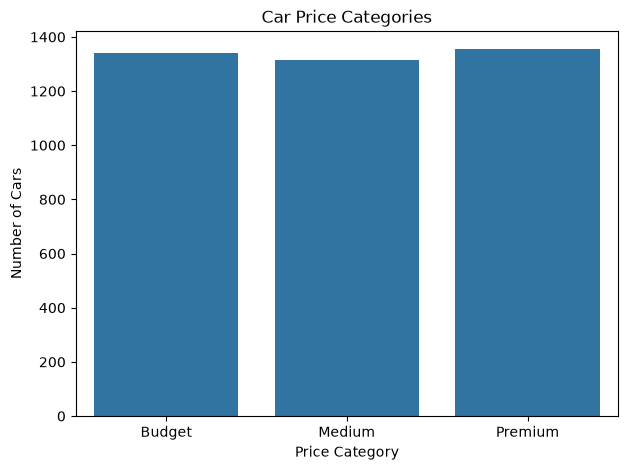

In [71]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="price_category")

plt.title("Car Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Number of Cars")
plt.show()


In [72]:
X_class = df.drop(["price", "price_category"], axis=1)
y_class = df["price_category"]

print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

X shape: (4009, 11)
y shape: (4009,)


In [73]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Training:", X_train_class.shape)
print("Testing :", X_test_class.shape)

Training: (3207, 11)
Testing : (802, 11)


In [77]:
numeric_transformer_class = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_class = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor_class = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_class, numerical_features),
        ("cat", categorical_transformer_class, categorical_features)
    ]
    )


In [79]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train_class, y_train_class)

logistic_pred = logistic_model.predict(X_test_class)
logistic_proba = logistic_model.predict_proba(X_test_class)


In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

logistic_accuracy = accuracy_score(
    y_test_class,
    logistic_pred
)

logistic_precision = precision_score(
    y_test_class,
    logistic_pred,
    average="weighted"
)

logistic_recall = recall_score(
    y_test_class,
    logistic_pred,
    average="weighted"
)

logistic_auc = roc_auc_score(
    y_test_class,
    logistic_proba,
    multi_class="ovr"
)

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("ROC-AUC  :", round(logistic_auc, 4))


Accuracy : 0.8092
Precision: 0.8069
Recall   : 0.8092
ROC-AUC  : 0.9418


In [82]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]
)

knn_model.fit(X_train_class, y_train_class)

knn_pred = knn_model.predict(X_test_class)
knn_proba = knn_model.predict_proba(X_test_class)


In [83]:
knn_accuracy = accuracy_score(y_test_class, knn_pred)

knn_precision = precision_score(
    y_test_class,
    knn_pred,
    average="weighted"
)

knn_recall = recall_score(
    y_test_class,
    knn_pred,
    average="weighted"
)

knn_auc = roc_auc_score(
    y_test_class,
    knn_proba,
    multi_class="ovr"
)

print("Accuracy :", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall   :", round(knn_recall, 4))
print("ROC-AUC  :", round(knn_auc, 4))

Accuracy : 0.7419
Precision: 0.7398
Recall   : 0.7419
ROC-AUC  : 0.8785


In [86]:
from sklearn.svm import SVC

svm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]
)

svm_model.fit(X_train_class, y_train_class)

svm_pred = svm_model.predict(X_test_class)
svm_proba = svm_model.predict_proba(X_test_class)

In [87]:
svm_accuracy = accuracy_score(y_test_class, svm_pred)

svm_precision = precision_score(
    y_test_class,
    svm_pred,
    average="weighted"
)

svm_recall = recall_score(
    y_test_class,
    svm_pred,
    average="weighted"
)

svm_auc = roc_auc_score(
    y_test_class,
    svm_proba,
    multi_class="ovr"
)

print("Accuracy :", round(svm_accuracy, 4))
print("Precision:", round(svm_precision, 4))
print("Recall   :", round(svm_recall, 4))
print("ROC-AUC  :", round(svm_auc, 4))

Accuracy : 0.7918
Precision: 0.7912
Recall   : 0.7918
ROC-AUC  : 0.9313


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


preprocessor_nb = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)


nb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_nb),
        ("model", GaussianNB())
    ]
)


nb_model.fit(X_train_class, y_train_class)


nb_pred = nb_model.predict(X_test_class)


nb_proba = nb_model.predict_proba(X_test_class)


In [91]:
nb_accuracy = accuracy_score(y_test_class, nb_pred)

nb_precision = precision_score(
    y_test_class,
    nb_pred,
    average="weighted"
)

nb_recall = recall_score(
    y_test_class,
    nb_pred,
    average="weighted"
)

nb_auc = roc_auc_score(
    y_test_class,
    nb_proba,
    multi_class="ovr"
)

print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("ROC-AUC  :", round(nb_auc, 4))

Accuracy : 0.7095
Precision: 0.7446
Recall   : 0.7095
ROC-AUC  : 0.8458


In [92]:
from sklearn.ensemble import RandomForestClassifier

rf_class_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_class),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_class_model.fit(X_train_class, y_train_class)

rf_class_pred = rf_class_model.predict(X_test_class)
rf_class_proba = rf_class_model.predict_proba(X_test_class)


In [93]:
rf_class_accuracy = accuracy_score(
    y_test_class,
    rf_class_pred
)

rf_class_precision = precision_score(
    y_test_class,
    rf_class_pred,
    average="weighted"
)

rf_class_recall = recall_score(
    y_test_class,
    rf_class_pred,
    average="weighted"
)

rf_class_auc = roc_auc_score(
    y_test_class,
    rf_class_proba,
    multi_class="ovr"
)

print("Accuracy :", round(rf_class_accuracy, 4))
print("Precision:", round(rf_class_precision, 4))
print("Recall   :", round(rf_class_recall, 4))
print("ROC-AUC  :", round(rf_class_auc, 4))

Accuracy : 0.7269
Precision: 0.7237
Recall   : 0.7269
ROC-AUC  : 0.8948


In [94]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "SVM",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy,
        svm_accuracy,
        nb_accuracy,
        rf_class_accuracy
    ],
    "Precision": [
        logistic_precision,
        knn_precision,
        svm_precision,
        nb_precision,
        rf_class_precision
    ],
    "Recall": [
        logistic_recall,
        knn_recall,
        svm_recall,
        nb_recall,
        rf_class_recall
    ],
    "ROC-AUC": [
        logistic_auc,
        knn_auc,
        svm_auc,
        nb_auc,
        rf_class_auc
    ]
})

classification_results.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.809227,0.806925,0.809227,0.941847
2,SVM,0.791771,0.791182,0.791771,0.931325
4,Random Forest,0.726933,0.723720,0.726933,0.894769
1,KNN,0.741895,0.739824,0.741895,0.878541
3,Naive Bayes,0.709476,0.744597,0.709476,0.845759


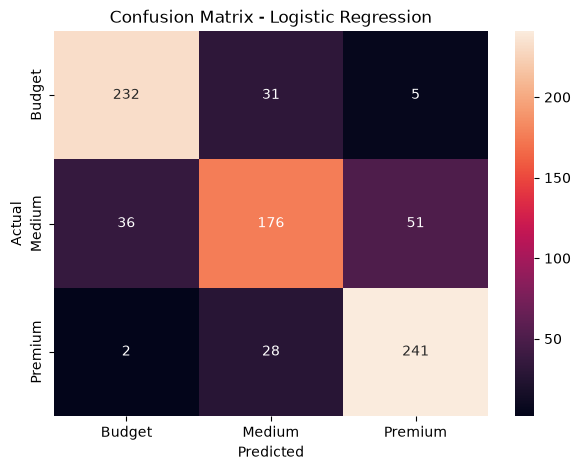

In [95]:
from sklearn.metrics import confusion_matrix

best_class_model_name = classification_results.loc[
    classification_results["ROC-AUC"].idxmax(),
    "Model"
]

predictions = {
    "Logistic Regression": logistic_pred,
    "KNN": knn_pred,
    "SVM": svm_pred,
    "Naive Bayes": nb_pred,
    "Random Forest": rf_class_pred
}

best_class_pred = predictions[best_class_model_name]

cm = confusion_matrix(
    y_test_class,
    best_class_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Budget", "Medium", "Premium"],
    yticklabels=["Budget", "Medium", "Premium"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_class_model_name}")
plt.show()

In [96]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_class,
        best_class_pred
    )
)

              precision    recall  f1-score   support

      Budget       0.86      0.87      0.86       268
      Medium       0.75      0.67      0.71       263
     Premium       0.81      0.89      0.85       271

    accuracy                           0.81       802
   macro avg       0.81      0.81      0.81       802
weighted avg       0.81      0.81      0.81       802



In [98]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

X_cluster = X.copy()

numerical_features_cluster = X_cluster.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_cluster = X_cluster.select_dtypes(
    exclude=np.number
).columns.tolist()

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features_cluster),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features_cluster)
    ]
)

X_cluster_scaled = cluster_preprocessor.fit_transform(X_cluster)

print(X_cluster_scaled.shape)

(4009, 3653)


In [99]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

kmeans_silhouette = silhouette_score(X_cluster_scaled, kmeans_labels)

print("K-Means:", kmeans_silhouette)
print(pd.Series(kmeans_labels).value_counts())

K-Means: 0.06444789087786057
0    1678
2    1547
1     784
Name: count, dtype: int64


In [100]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)

hierarchical_labels = hierarchical.fit_predict(X_cluster_scaled)

hierarchical_silhouette = silhouette_score(
    X_cluster_scaled,
    hierarchical_labels
)

print("Hierarchical:", hierarchical_silhouette)
print(pd.Series(hierarchical_labels).value_counts())

Hierarchical: 0.05923475151374112
1    2273
0    1110
2     626
Name: count, dtype: int64


In [101]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

print(pd.Series(dbscan_labels).value_counts())

mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(
        X_cluster_scaled[mask],
        dbscan_labels[mask]
    )
    print("DBSCAN:", dbscan_silhouette)

-1    4009
Name: count, dtype: int64


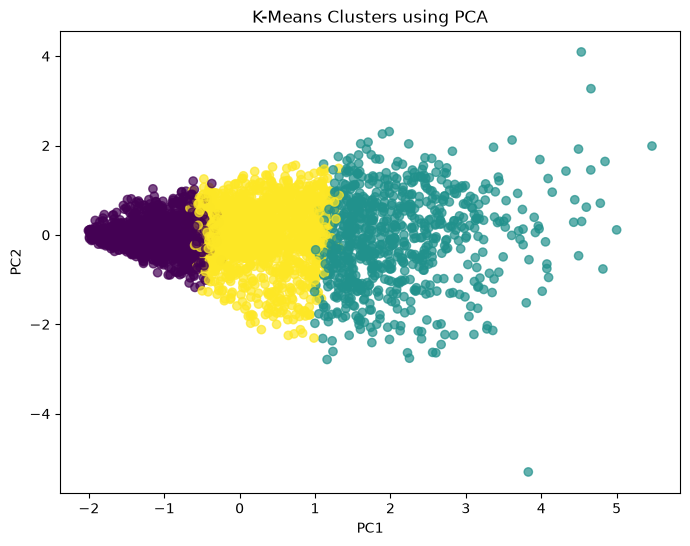

In [102]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters using PCA")
plt.show()

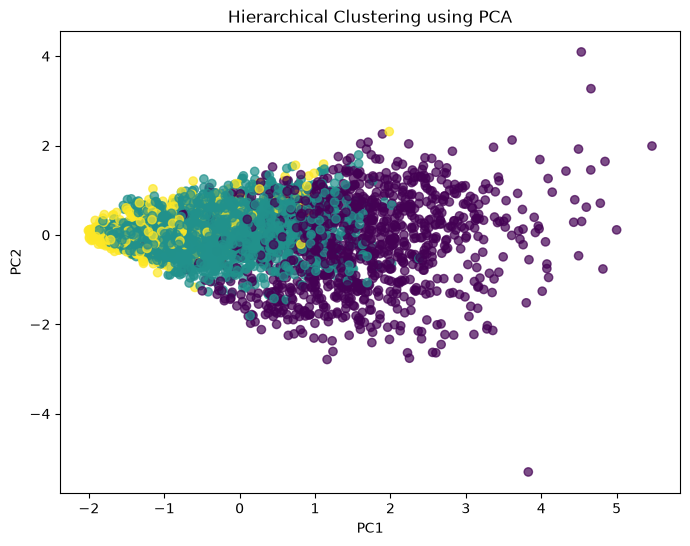

In [103]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clustering using PCA")
plt.show()

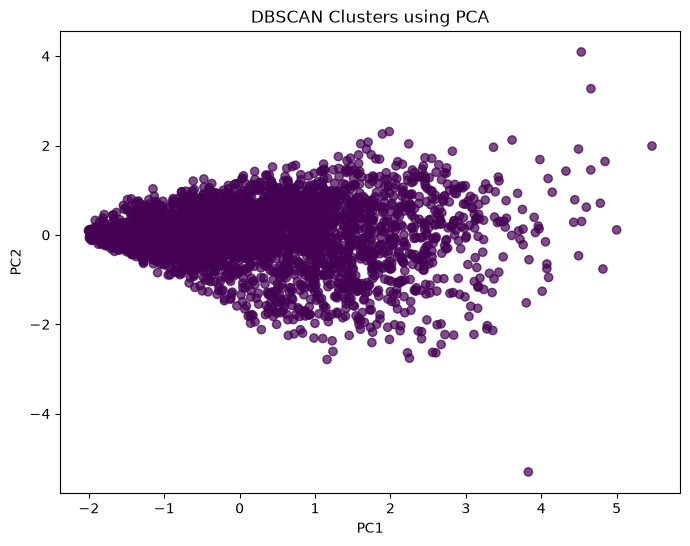

In [104]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters using PCA")
plt.show()

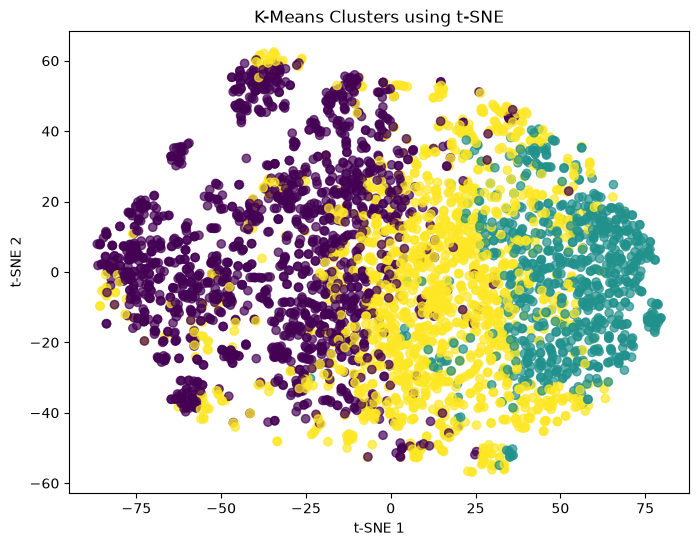

In [105]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    alpha=0.7
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Clusters using t-SNE")
plt.show()

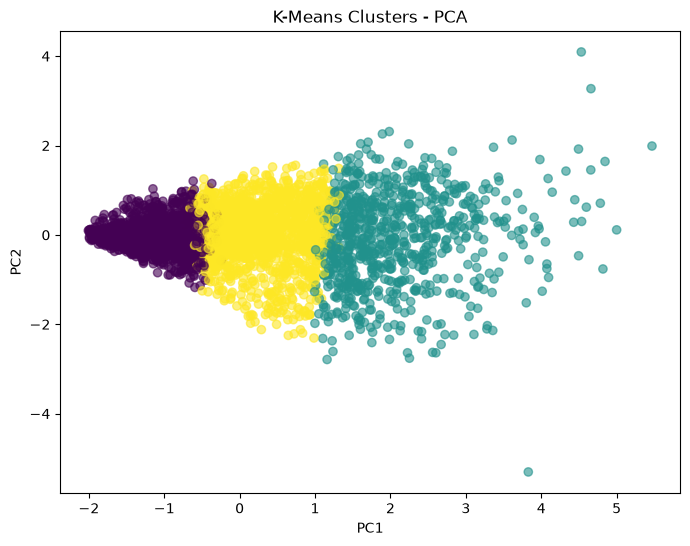

Explained Variance: [0.20555387 0.05039876]


In [106]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, alpha=0.6)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters - PCA")
plt.show()

print("Explained Variance:", pca.explained_variance_ratio_)

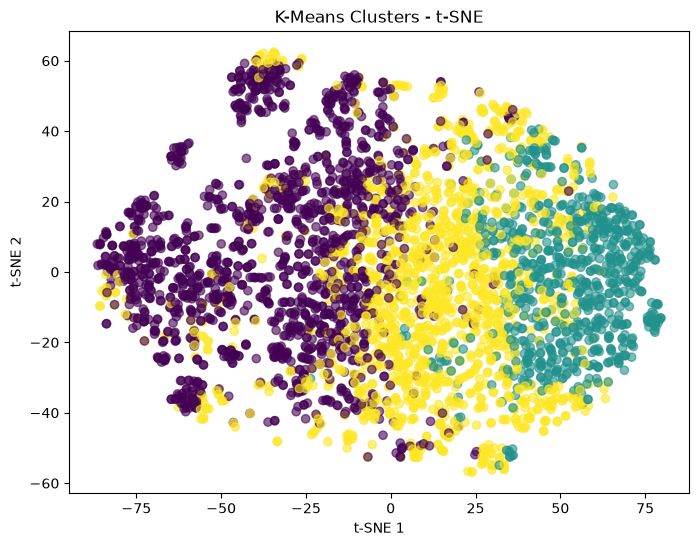

In [107]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    alpha=0.6
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means Clusters - t-SNE")
plt.show()

In [108]:
cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels

cluster_summary = cluster_data.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,model_year,milage
Cluster,,
0,2020.467223,23073.016687
1,2006.670918,137445.501276
2,2014.627020,73030.941823


In [109]:
cluster_summary.T

Cluster,0,1,2
model_year,2020.467223,2006.670918,2014.627020
milage,23073.016687,137445.501276,73030.941823


In [110]:
cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels

cluster_summary = cluster_data.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary.T)

Cluster                0              1             2
model_year   2020.467223    2006.670918   2014.627020
milage      23073.016687  137445.501276  73030.941823


In [111]:
cluster_data = X.copy()
cluster_data["Cluster"] = kmeans_labels
cluster_data["price"] = y.values

print(cluster_data.groupby("Cluster").mean(numeric_only=True).T)

Cluster                0              1             2
model_year   2020.467223    2006.670918   2014.627020
milage      23073.016687  137445.501276  73030.941823
price       68230.383194   13426.533163  34645.607628


In [114]:
results = pd.DataFrame({
    "Model": [
        "K-Means",
        "Hierarchical"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

results.sort_values("Silhouette Score", ascending=False)

,Model,Silhouette Score
0,K-Means,0.064448
1,Hierarchical,0.059235


In [116]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(cluster_preprocessor, "cluster_preprocessor.pkl")

['cluster_preprocessor.pkl']

In [117]:
print(X.columns.tolist())


['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


In [119]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import joblib

price_model = Pipeline([
    ("preprocessor", cluster_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

price_model.fit(X, y)

joblib.dump(price_model, "price_model.pkl")


['price_model.pkl']

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(
    X, y, test_size=0.2, random_state=42
)

price_model.fit(X_train_price, y_train_price)

price_pred = price_model.predict(X_test_price)

mae = mean_absolute_error(y_test_price, price_pred)
rmse = np.sqrt(mean_squared_error(y_test_price, price_pred))
r2 = r2_score(y_test_price, price_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 19008.33374064838
RMSE: 134913.71127925738
R2 Score: 0.10948671823218181


In [121]:
print(y.describe())

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


In [122]:
print("Max price:", y.max())
print("Min price:", y.min())

Max price: 2954083.0
Min price: 2000.0


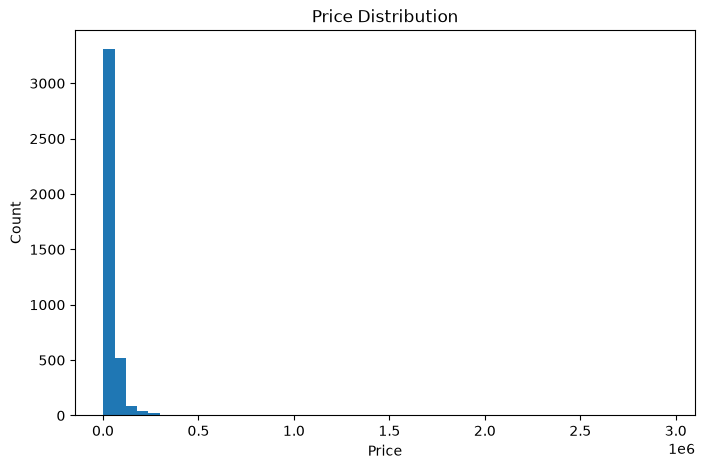

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(y, bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()